# De Bruijn GraphCL + GAT for Human non-TATA Promoter Classification

This notebook is cleaned and ordered from start to finish.

**Main pipeline:**

`DNA sequence → preprocessing → De Bruijn graph → GraphCL pretraining → GAT fine-tuning → evaluation`

**Better stable setup used here:**
- `K = 6`
- De Bruijn graph nodes = `(K-1)`-mers
- GAT encoder with learned k-mer embedding
- GraphCL projection head
- Best checkpoint selected using **Validation F1**
- Includes a clear graph construction example and visualization

In [8]:
# Run this once in Kaggle/Colab if packages are missing
!pip install -q genomic-benchmarks torch-geometric networkx

## 1. Imports

Run this cell first. If any library is missing, install it in your environment before running the full notebook.

In [9]:
# Install if needed
!pip install genomic-benchmarks

# Correct import
from genomic_benchmarks.dataset_getters.pytorch_datasets import get_dataset

# Other imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

print("Imports completed.")

/usr/local/lib/python3.12/dist-packages/genomic_benchmarks/utils/datasets.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Imports completed.


## 2. Reproducibility and Final Hyperparameters

This setup is chosen based on your previous best stable result. Do not change many values at once.

In [10]:
SEED = 42
K = 6
BATCH_SIZE = 32
VAL_RATIO = 0.20
EMB_DIM = 96
NUM_KMER_NODES = 4 ** (K - 1)
# Model size
EMB_DIM = 64
HIDDEN_DIM = 384
HEADS = 6

# Training length
PRETRAIN_EPOCHS = 100
CLASSIFIER_EPOCHS = 80

# Learning rates
SSL_LR = 1e-4
CLS_LR = 6e-5
ENCODER_FINETUNE_LR = 5e-6

# Regularization
WEIGHT_DECAY = 1e-4
DROPOUT_ENCODER = 0.15
DROPOUT_CLASSIFIER = 0.30
LABEL_SMOOTHING = 0.02

# GraphCL
TEMP = 0.5
EDGE_DROP_RATE = 0.10
NODE_MASK_RATE = 0.10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("K-mer size:", K)

Using device: cuda
K-mer size: 6


## 3. Load Dataset

This loads the human non-TATA promoter dataset and converts it into a dataframe.

In [11]:
train_raw = get_dataset("human_nontata_promoters", split="train")
test_raw  = get_dataset("human_nontata_promoters", split="test")

print("Raw train samples:", len(train_raw))
print("Raw test samples :", len(test_raw))

def dataset_to_dataframe(dataset):
    sequences, labels = [], []
    for seq, label in dataset:
        sequences.append(str(seq).upper())
        labels.append(int(label))
    return pd.DataFrame({
        "sequence": sequences,
        "label": labels,
        "sequence_length": [len(s) for s in sequences]
    })

full_train_df = dataset_to_dataframe(train_raw)
test_df = dataset_to_dataframe(test_raw)

print("Full training dataframe shape:", full_train_df.shape)
print("Test dataframe shape:", test_df.shape)

display(full_train_df.head())
display(test_df.head())

/usr/local/lib/python3.12/dist-packages/genomic_benchmarks/utils/datasets.py:50: UserWarning: No version specified. Using version 0.
  warnings.warn(f"No version specified. Using version {metadata['version']}.")


Raw train samples: 27097
Raw test samples : 9034
Full training dataframe shape: (27097, 3)
Test dataframe shape: (9034, 3)


,sequence,label,sequence_length
0,GGCCACTGCACTCCAGCCGGGTTGACAGAGGGAGACTCCATCCCAA...,0,251
1,AGGTGCGATCCCTTCTCCTTTGGGGTTTACTTTCTCAGAGAAAAAA...,0,251
2,AGCCCTCGACCCCCACAGGCAGTGGCTCCAGGCTGTTGGGGAGGAT...,0,251
3,AAGGTACCTTTGCTTCCAGGGGAAACCAATTCTGCCTACTTGGGAA...,0,251
4,AGAAACGGGCGGGTTATTGACGAGTTCCCTCCCTCTCGCAGTTTTA...,0,251


,sequence,label,sequence_length
0,TGCTCTCAAGTCTCACCTTTTACAGTAGAGAGGACTAACGGCTTAT...,0,251
1,ACCTCAGGTGATCCGCCGCCTCAGCCTCCCAAAGTGCTTAGGATTA...,0,251
2,GGTCATGGATGTCGGAAATAAAGGTGTGAAAAAGAAGAGGAGGAAT...,0,251
3,GCTCGCCGGACCAGTCTGGCAGCGCCCGGGCTCGGATTTCAAAGCC...,0,251
4,TGGCCCTCCTGCGTCCCGGCTTCGGGTCAGCATGACAGCGTGAAAC...,0,251


## 4. Preprocessing Summary

Here you can show dataset information before graph conversion.

In [12]:
print("Training label distribution:")
display(full_train_df["label"].value_counts().sort_index().rename("count").to_frame())

print("Test label distribution:")
display(test_df["label"].value_counts().sort_index().rename("count").to_frame())

print("Sequence length summary - train:")
display(full_train_df["sequence_length"].describe().to_frame())

print("Sequence length summary - test:")
display(test_df["sequence_length"].describe().to_frame())

Training label distribution:


,count
label,
0,14742
1,12355


Test label distribution:


,count
label,
0,4915
1,4119


Sequence length summary - train:


,sequence_length
count,27097.0
mean,251.0
std,0.0
min,251.0
25%,251.0
50%,251.0
75%,251.0
max,251.0


Sequence length summary - test:


,sequence_length
count,9034.0
mean,251.0
std,0.0
min,251.0
25%,251.0
50%,251.0
75%,251.0
max,251.0


## 5. Train/Validation Split

The official test set is kept untouched. The original train set is split into training and validation.

In [13]:
train_df, val_df = train_test_split(
    full_train_df,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=full_train_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (21677, 3)
Val shape  : (5420, 3)
Test shape : (9034, 3)


,sequence,label,sequence_length
0,AGGCAGGAGAATTGCTTGAACCTGGGAGGTAGAGGCTGCGGTGAGC...,1,251
1,GCGCGCCCAGCGCCCCTGGCACAGCCAACGGGCACCCCGGGCCGCG...,0,251
2,CACCTCCTCGCCTCCTCTTCTTCCTCCTCTTCCTCACCCCCATGGA...,1,251
3,AGGGAAGAATTCCAGATGGGGAGAAAGTAATATTTTGCAGCACAGT...,0,251
4,TGTGTACACATATTGACCAAATCAGGGTAATTTTGCATTTGTAATT...,1,251


## 6. De Bruijn Graph Preprocessing Functions

For `K = 6`:

- Each **node** is a 5-mer, meaning `(K-1)` bases.
- Each **edge** comes from a 6-mer overlap.

Example: `GGCCAC`
- prefix node = `GGCCA`
- suffix node = `GCCAC`
- edge = `GGCCA → GCCAC`

For GAT, reverse edges are also added so message passing works in both directions.

In [14]:
BASE_TO_ID = {"A": 0, "C": 1, "G": 2, "T": 3}
ID_TO_BASE = {v: k for k, v in BASE_TO_ID.items()}

def is_valid_dna(text):
    return all(ch in BASE_TO_ID for ch in text)

def kmer_to_id(kmer):
    """Convert DNA k-mer into base-4 integer ID."""
    idx = 0
    for ch in kmer:
        idx = idx * 4 + BASE_TO_ID[ch]
    return idx

def id_to_kmer(idx, length):
    """Convert base-4 integer ID back to DNA k-mer."""
    chars = []
    for _ in range(length):
        chars.append(ID_TO_BASE[idx % 4])
        idx //= 4
    return "".join(reversed(chars))

def build_debruijn_graph(sequence, label, k=6):
    sequence = str(sequence).upper()

    node_map = {}
    node_to_kmer = {}
    node_ids = []
    directed_edges = []
    valid_kmers = 0

    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i + k]

        if not is_valid_dna(kmer):
            continue

        valid_kmers += 1

        prefix = kmer[:-1]
        suffix = kmer[1:]

        if prefix not in node_map:
            node_map[prefix] = len(node_map)
            node_ids.append(kmer_to_id(prefix))
            node_to_kmer[node_map[prefix]] = prefix

        if suffix not in node_map:
            node_map[suffix] = len(node_map)
            node_ids.append(kmer_to_id(suffix))
            node_to_kmer[node_map[suffix]] = suffix

        u = node_map[prefix]
        v = node_map[suffix]

        # Forward biological direction and reverse direction for GAT message passing.
        directed_edges.append([u, v])
        directed_edges.append([v, u])

    if len(node_ids) == 0:
        node_ids = [0]
        directed_edges = [[0, 0]]
        node_to_kmer[0] = "N" * (k - 1)
        valid_kmers = 0

    x = torch.tensor(node_ids, dtype=torch.long)
    edge_index = torch.tensor(directed_edges, dtype=torch.long).t().contiguous()
    y = torch.tensor([int(label)], dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.num_valid_kmers = torch.tensor([valid_kmers], dtype=torch.long)
    data.original_length = torch.tensor([len(sequence)], dtype=torch.long)

    # Helpful for explanation and visualization only.
    data.node_to_kmer = node_to_kmer
    data.node_map = node_map

    return data

def create_graph_dataset(df, k=6):
    graphs = []
    for _, row in df.iterrows():
        graphs.append(build_debruijn_graph(row["sequence"], row["label"], k=k))
    return graphs

print("Preprocessing functions are ready.")

Preprocessing functions are ready.


## 7. One Real Sequence → De Bruijn Graph Example

This section is for understanding and presentation. It shows exactly how a DNA sequence becomes a graph.

In [15]:
# Show how one DNA sequence becomes a De Bruijn graph

sample_seq = full_train_df.iloc[0]["sequence"]
sample_label = full_train_df.iloc[0]["label"]

print("Original Sequence (first 50 chars):")
print(sample_seq[:50])
print("Label:", sample_label)

print("\nFirst few K-mers:")
for i in range(5):
    kmer = sample_seq[i:i+K]
    print(f"{i+1}. {kmer}")

print("\nDe Bruijn Graph Construction:")
for i in range(5):
    kmer = sample_seq[i:i+K]
    prefix = kmer[:-1]
    suffix = kmer[1:]

    print(f"K-mer: {kmer}")
    print(f"Prefix Node: {prefix}")
    print(f"Suffix Node: {suffix}")
    print(f"Edge: {prefix} → {suffix}")
    print("-" * 40)

sample_graph = build_debruijn_graph(sample_seq, sample_label, k=K)

print("\nFinal Graph Summary:")
print(f"Total Nodes: {sample_graph.num_nodes}")
print(f"Total Edges: {sample_graph.edge_index.shape[1]}")
print(f"Graph Label: {sample_graph.y.item()}")

Original Sequence (first 50 chars):
GGCCACTGCACTCCAGCCGGGTTGACAGAGGGAGACTCCATCCCAAAAAA
Label: 0

First few K-mers:
1. GGCCAC
2. GCCACT
3. CCACTG
4. CACTGC
5. ACTGCA

De Bruijn Graph Construction:
K-mer: GGCCAC
Prefix Node: GGCCA
Suffix Node: GCCAC
Edge: GGCCA → GCCAC
----------------------------------------
K-mer: GCCACT
Prefix Node: GCCAC
Suffix Node: CCACT
Edge: GCCAC → CCACT
----------------------------------------
K-mer: CCACTG
Prefix Node: CCACT
Suffix Node: CACTG
Edge: CCACT → CACTG
----------------------------------------
K-mer: CACTGC
Prefix Node: CACTG
Suffix Node: ACTGC
Edge: CACTG → ACTGC
----------------------------------------
K-mer: ACTGCA
Prefix Node: ACTGC
Suffix Node: CTGCA
Edge: ACTGC → CTGCA
----------------------------------------

Final Graph Summary:
Total Nodes: 196
Total Edges: 492
Graph Label: 0


## 8. Graph Table View After Conversion

This is like `df.head()`, but for graph nodes and edges.

In [16]:
# Node table
node_rows = []
for node_idx, kmer_text in list(sample_graph.node_to_kmer.items())[:15]:
    node_rows.append({
        "node_index": node_idx,
        "dna_node_(K-1)-mer": kmer_text,
        "numeric_id_used_by_embedding": int(sample_graph.x[node_idx].item())
    })
node_table = pd.DataFrame(node_rows)

# Edge table
edge_np = sample_graph.edge_index.cpu().numpy().T
edge_rows = []
for u, v in edge_np[:20]:
    u, v = int(u), int(v)
    edge_rows.append({
        "source_index": u,
        "source_DNA_node": sample_graph.node_to_kmer[u],
        "target_index": v,
        "target_DNA_node": sample_graph.node_to_kmer[v]
    })
edge_table = pd.DataFrame(edge_rows)

print("Node table:")
display(node_table)

print("Edge table:")
display(edge_table)

Node table:


,node_index,dna_node_(K-1)-mer,numeric_id_used_by_embedding
0,0,GGCCA,660
1,1,GCCAC,593
2,2,CCACT,327
3,3,CACTG,286
4,4,ACTGC,121
5,5,CTGCA,484
6,6,TGCAC,913
7,7,GCACT,583
8,8,CACTC,285
9,9,ACTCC,117


Edge table:


,source_index,source_DNA_node,target_index,target_DNA_node
0,0,GGCCA,1,GCCAC
1,1,GCCAC,0,GGCCA
2,1,GCCAC,2,CCACT
3,2,CCACT,1,GCCAC
4,2,CCACT,3,CACTG
5,3,CACTG,2,CCACT
6,3,CACTG,4,ACTGC
7,4,ACTGC,3,CACTG
8,4,ACTGC,5,CTGCA
9,5,CTGCA,4,ACTGC


## 9. Sample Graph Visualization

This graph shows the actual DNA nodes. Both-side arrows appear because reverse edges are added for GAT message passing.

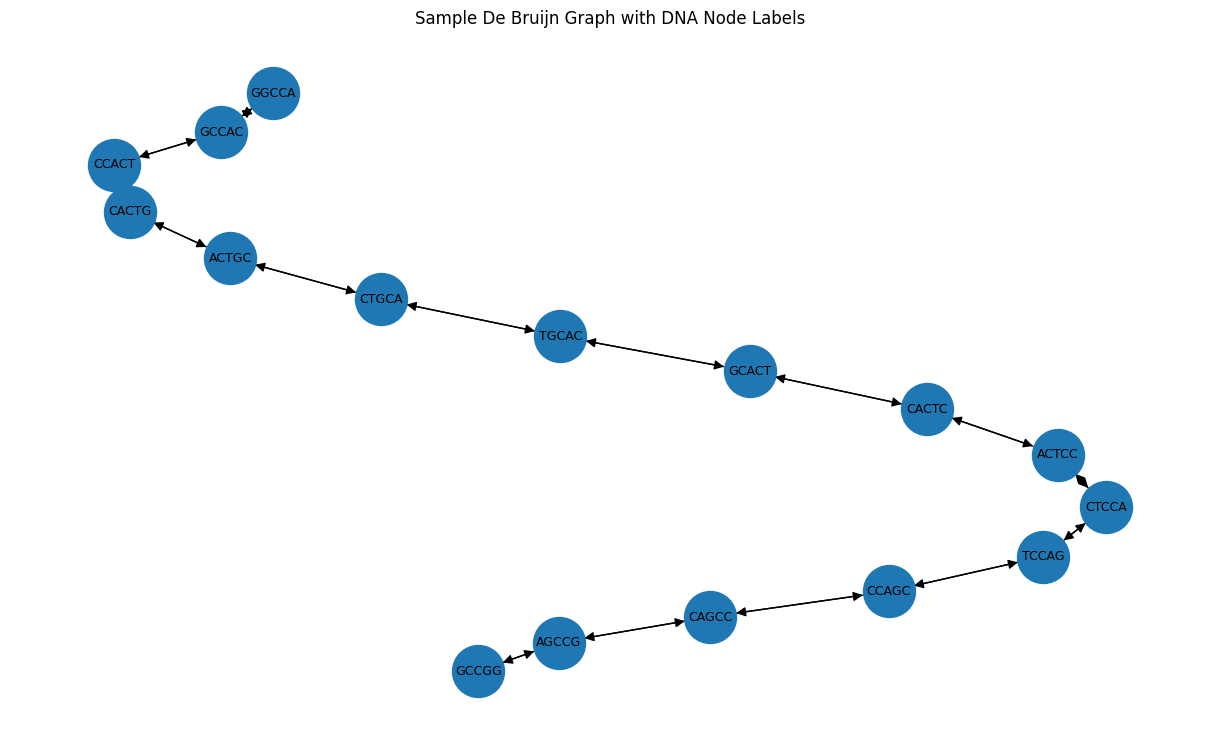

In [17]:
import networkx as nx

G_vis = nx.DiGraph()
edge_np = sample_graph.edge_index.cpu().numpy().T
node_labels = {}

# Show only first 30 directed edges to keep the graph readable.
for u, v in edge_np[:30]:
    u, v = int(u), int(v)
    G_vis.add_edge(u, v)
    node_labels[u] = sample_graph.node_to_kmer[u]
    node_labels[v] = sample_graph.node_to_kmer[v]

plt.figure(figsize=(12, 7))
pos = nx.spring_layout(G_vis, seed=42)

nx.draw(
    G_vis,
    pos,
    with_labels=False,
    node_size=1400,
    arrows=True,
    arrowsize=14
)

nx.draw_networkx_labels(
    G_vis,
    pos,
    labels=node_labels,
    font_size=9
)

plt.title("Sample De Bruijn Graph with DNA Node Labels")
plt.axis("off")
plt.show()

## 10. Convert Full Dataset to Graphs

This may take a little time.

In [18]:
train_graphs = create_graph_dataset(train_df, k=K)
val_graphs = create_graph_dataset(val_df, k=K)
test_graphs = create_graph_dataset(test_df, k=K)

print("Train graphs:", len(train_graphs))
print("Val graphs  :", len(val_graphs))
print("Test graphs :", len(test_graphs))



Train graphs: 21677
Val graphs  : 5420
Test graphs : 9034


In [19]:
def remove_graph_metadata(graphs):
    for g in graphs:
        if hasattr(g, "node_to_kmer"):
            del g.node_to_kmer
        if hasattr(g, "node_map"):
            del g.node_map
    return graphs

train_graphs = remove_graph_metadata(train_graphs)
val_graphs = remove_graph_metadata(val_graphs)
test_graphs = remove_graph_metadata(test_graphs)

## 11. DataLoaders and Class Weights

In [20]:
train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# Class weights from training labels
train_labels_np = train_df["label"].values
class_counts = np.bincount(train_labels_np)
class_weights_np = class_counts.sum() / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [11793  9884]
Class weights: tensor([0.9191, 1.0966], device='cuda:0')


## 12. GraphCL Augmentations

These create two slightly different views of the same graph for contrastive learning.

In [21]:
def drop_edges(data, drop_rate=0.10):
    edge_index = data.edge_index
    num_edges = edge_index.size(1)

    if num_edges <= 1:
        return data

    keep_mask = torch.rand(num_edges, device=edge_index.device) > drop_rate
    if keep_mask.sum() == 0:
        keep_mask[torch.randint(0, num_edges, (1,), device=edge_index.device)] = True

    new_data = data.clone()
    new_data.edge_index = edge_index[:, keep_mask]
    return new_data

def mask_nodes(data, mask_rate=0.10):
    new_data = data.clone()
    x = new_data.x.clone()

    num_nodes = x.size(0)
    if num_nodes <= 1:
        return new_data

    mask = torch.rand(num_nodes, device=x.device) < mask_rate
    if mask.sum() > 0:
        # mask ID 0 corresponds to AAAAA for 5-mer; works as a simple neutral mask token here
        x[mask] = 0
    new_data.x = x
    return new_data

def random_graph_augment(data):
    choice = random.choice(["drop", "mask", "both", "none"])
    if choice == "drop":
        return drop_edges(data, EDGE_DROP_RATE)
    elif choice == "mask":
        return mask_nodes(data, NODE_MASK_RATE)
    elif choice == "both":
        return mask_nodes(drop_edges(data, EDGE_DROP_RATE), NODE_MASK_RATE)
    else:
        return data.clone()

print("GraphCL augmentation functions are ready.")

GraphCL augmentation functions are ready.


## 13. Model Definition: GAT Encoder + Projection Head + Classifier

In [22]:
class GATEncoder(nn.Module):
    def __init__(self, num_kmers, emb_dim, hidden_dim, heads, dropout):
        super().__init__()

        self.embedding = nn.Embedding(num_kmers, emb_dim)

        self.gat1 = GATConv(
            emb_dim,
            hidden_dim // heads,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_dim,
            hidden_dim // heads,
            heads=heads,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch):
        x = self.embedding(x)   # ✅ k-mer ID → learned feature vector

        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.gat2(x, edge_index)
        x = F.elu(x)

        graph_emb = global_mean_pool(x, batch)
        return graph_emb

class GraphCLModel(nn.Module):
    def __init__(self, encoder, hidden_dim, proj_dim=128):
        super().__init__()

        self.encoder = encoder

        self.projector = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, proj_dim)
        )

    def forward(self, x, edge_index, batch):
        h = self.encoder(x, edge_index, batch)
        z = self.projector(h)
        return z

class GATClassifier(nn.Module):
    def __init__(self, encoder, hidden_dim=256, num_classes=2, dropout=0.55):
        super().__init__()
        self.encoder = encoder
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, edge_index, batch):
        emb = self.encoder(x, edge_index, batch)
        return self.fc(emb)

num_kmers = 4 ** (K - 1)
print("Number of possible (K-1)-mers:", num_kmers)

Number of possible (K-1)-mers: 1024


## 14. GraphCL Contrastive Loss

Do not worry if GraphCL loss is around 2.0–2.8. Contrastive loss scale is different from classification loss. The trend matters more than the absolute value.

In [23]:
def nt_xent_loss(z1, z2, temperature=0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)

    sim = torch.matmul(z, z.T) / temperature

    # remove self similarity
    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.arange(batch_size, 2 * batch_size, device=z.device),
        torch.arange(0, batch_size, device=z.device)
    ])

    loss = F.cross_entropy(sim, positives)
    return loss

print("Contrastive loss function is ready.")

Contrastive loss function is ready.


## 15. GraphCL Pretraining

This pretrains the GAT encoder using unlabeled graph views.

**Why 100 epochs?** It usually gives stable representation. If loss plateaus, you may stop at 60 for quick experiments, but for final comparison keep this setting consistent.

In [24]:
gat_encoder = GATEncoder(
    num_kmers=NUM_KMER_NODES,
    emb_dim=EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    heads=HEADS,
    dropout=DROPOUT_ENCODER
).to(device)

graphcl_model = GraphCLModel(
    encoder=gat_encoder,
    hidden_dim=HIDDEN_DIM,
    proj_dim=128
).to(device)

optimizer_ssl = torch.optim.AdamW(
    graphcl_model.parameters(),
    lr=SSL_LR,
    weight_decay=WEIGHT_DECAY
)

ssl_history = []

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    graphcl_model.train()
    total_loss = 0.0

    for data in train_loader:
        data = data.to(device)

        view1 = random_graph_augment(data).to(device)
        view2 = random_graph_augment(data).to(device)

        z1 = graphcl_model(view1.x, view1.edge_index, view1.batch)
        z2 = graphcl_model(view2.x, view2.edge_index, view2.batch)

        loss = nt_xent_loss(z1, z2, temperature=TEMP)

        optimizer_ssl.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(graphcl_model.parameters(), 1.0)
        optimizer_ssl.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    ssl_history.append(avg_loss)

    print(f"DeBruijn-GAT-GraphCL Epoch {epoch:03d} | Loss: {avg_loss:.4f}")

DeBruijn-GAT-GraphCL Epoch 001 | Loss: 2.6893
DeBruijn-GAT-GraphCL Epoch 002 | Loss: 2.5677
DeBruijn-GAT-GraphCL Epoch 003 | Loss: 2.5405
DeBruijn-GAT-GraphCL Epoch 004 | Loss: 2.5269
DeBruijn-GAT-GraphCL Epoch 005 | Loss: 2.5069
DeBruijn-GAT-GraphCL Epoch 006 | Loss: 2.4998
DeBruijn-GAT-GraphCL Epoch 007 | Loss: 2.4931
DeBruijn-GAT-GraphCL Epoch 008 | Loss: 2.4857
DeBruijn-GAT-GraphCL Epoch 009 | Loss: 2.4819
DeBruijn-GAT-GraphCL Epoch 010 | Loss: 2.4740
DeBruijn-GAT-GraphCL Epoch 011 | Loss: 2.4699
DeBruijn-GAT-GraphCL Epoch 012 | Loss: 2.4619
DeBruijn-GAT-GraphCL Epoch 013 | Loss: 2.4606
DeBruijn-GAT-GraphCL Epoch 014 | Loss: 2.4552
DeBruijn-GAT-GraphCL Epoch 015 | Loss: 2.4485
DeBruijn-GAT-GraphCL Epoch 016 | Loss: 2.4453
DeBruijn-GAT-GraphCL Epoch 017 | Loss: 2.4445
DeBruijn-GAT-GraphCL Epoch 018 | Loss: 2.4382
DeBruijn-GAT-GraphCL Epoch 019 | Loss: 2.4358
DeBruijn-GAT-GraphCL Epoch 020 | Loss: 2.4323
DeBruijn-GAT-GraphCL Epoch 021 | Loss: 2.4265
DeBruijn-GAT-GraphCL Epoch 022 | L

In [25]:
torch.save({
    "graphcl_model": graphcl_model.state_dict(),
    "encoder": gat_encoder.state_dict(),
    "optimizer": optimizer_ssl.state_dict(),
    "epoch": epoch
}, "pretrain_checkpoint.pt")

## 16. Plot GraphCL Pretraining Loss

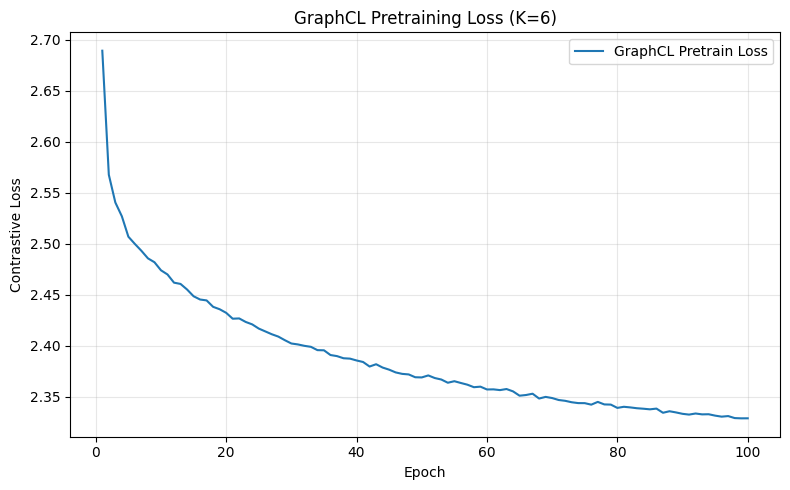

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ssl_history) + 1), ssl_history, label="GraphCL Pretrain Loss")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title(f"GraphCL Pretraining Loss (K={K})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 17. Fine-tuning Functions

The best model is selected using **Validation F1**, not only accuracy.

In [27]:
criterion_cls = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

def train_supervised(loader, model, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for data in loader:
        data = data.to(device)

        logits = model(data.x, data.edge_index, data.batch)
        loss = criterion_cls(logits, data.y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item()

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(data.y.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

@torch.no_grad()
def evaluate(loader, model, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    for data in loader:
        data = data.to(device)

        logits = model(data.x, data.edge_index, data.batch)
        loss = criterion_cls(logits, data.y)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return avg_loss, acc, f1, all_preds, all_labels, all_probs

print("Fine-tuning functions are ready.")

Fine-tuning functions are ready.


## 18. Fine-tune Classifier

This uses differential learning rates:
- low LR for pretrained encoder
- higher LR for classifier head

In [28]:
model = GATClassifier(
    encoder=gat_encoder,
    hidden_dim=HIDDEN_DIM,
    num_classes=2,
    dropout=DROPOUT_CLASSIFIER
).to(device)

optimizer_cls = torch.optim.AdamW(
    [
        {"params": model.encoder.parameters(), "lr": 2e-5},
        {"params": model.fc.parameters(), "lr": 1e-4}
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler_cls = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cls,
    mode="max",
    factor=0.5,
    patience=5
)

best_val_f1 = 0.0
best_val_acc = 0.0
best_val_loss = float("inf")
best_state = None

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_f1": []
}

for epoch in range(1, CLASSIFIER_EPOCHS + 1):
    train_loss, train_acc = train_supervised(train_loader, model, optimizer_cls, device)
    val_loss, val_acc, val_f1, _, _, _ = evaluate(val_loader, model, device)

    scheduler_cls.step(val_f1)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

print("Best Validation F1:", best_val_f1)
print("Best Validation Accuracy at best F1:", best_val_acc)
print("Best Validation Loss at best F1:", best_val_loss)

Epoch 001 | Train Loss: 0.4540 | Train Acc: 0.7957 | Val Loss: 0.4167 | Val Acc: 0.8212 | Val F1: 0.8244
Epoch 002 | Train Loss: 0.4316 | Train Acc: 0.8104 | Val Loss: 0.4050 | Val Acc: 0.8251 | Val F1: 0.8300
Epoch 003 | Train Loss: 0.4218 | Train Acc: 0.8150 | Val Loss: 0.3990 | Val Acc: 0.8288 | Val F1: 0.8339
Epoch 004 | Train Loss: 0.4156 | Train Acc: 0.8196 | Val Loss: 0.3973 | Val Acc: 0.8362 | Val F1: 0.8351
Epoch 005 | Train Loss: 0.4087 | Train Acc: 0.8233 | Val Loss: 0.3861 | Val Acc: 0.8389 | Val F1: 0.8406
Epoch 006 | Train Loss: 0.4041 | Train Acc: 0.8238 | Val Loss: 0.3837 | Val Acc: 0.8384 | Val F1: 0.8383
Epoch 007 | Train Loss: 0.3980 | Train Acc: 0.8276 | Val Loss: 0.3780 | Val Acc: 0.8417 | Val F1: 0.8429
Epoch 008 | Train Loss: 0.3927 | Train Acc: 0.8306 | Val Loss: 0.3787 | Val Acc: 0.8399 | Val F1: 0.8437
Epoch 009 | Train Loss: 0.3876 | Train Acc: 0.8337 | Val Loss: 0.3700 | Val Acc: 0.8511 | Val F1: 0.8508
Epoch 010 | Train Loss: 0.3857 | Train Acc: 0.8335 | Va

In [29]:
torch.save({
    "model_state": best_state,
    "best_val_f1": best_val_f1,
    "best_val_acc": best_val_acc,
    "best_val_loss": best_val_loss,
    "history": history
}, "best_classifier_checkpoint.pt")

print("Full checkpoint saved!")

Full checkpoint saved!


## 19. Plot Fine-tuning Loss and Accuracy/F1

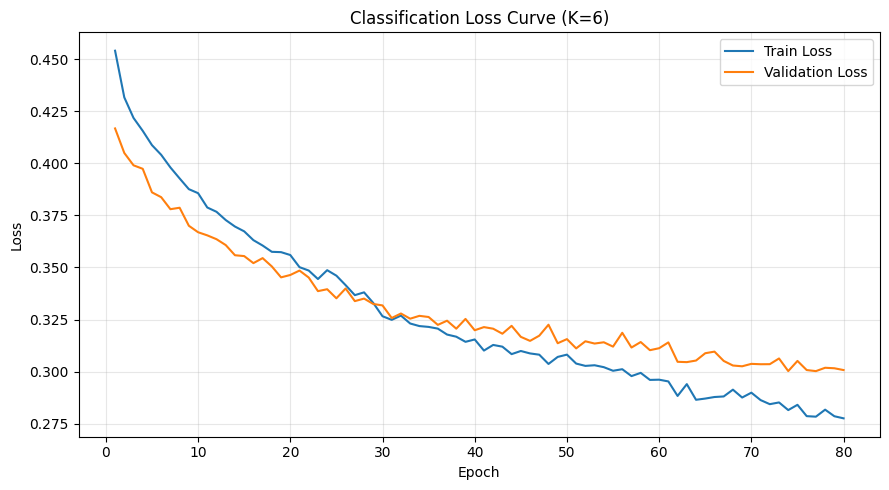

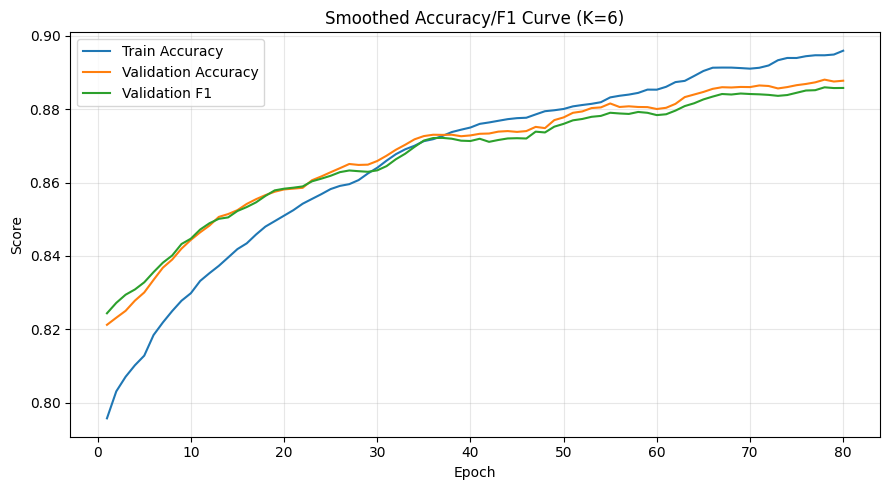

In [30]:
hist_df = pd.DataFrame(history)

plt.figure(figsize=(9, 5))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Classification Loss Curve (K={K})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

window = 5
hist_df["train_acc_smooth"] = hist_df["train_acc"].rolling(window, min_periods=1).mean()
hist_df["val_acc_smooth"] = hist_df["val_acc"].rolling(window, min_periods=1).mean()
hist_df["val_f1_smooth"] = hist_df["val_f1"].rolling(window, min_periods=1).mean()

plt.figure(figsize=(9, 5))
plt.plot(hist_df["epoch"], hist_df["train_acc_smooth"], label="Train Accuracy")
plt.plot(hist_df["epoch"], hist_df["val_acc_smooth"], label="Validation Accuracy")
plt.plot(hist_df["epoch"], hist_df["val_f1_smooth"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title(f"Smoothed Accuracy/F1 Curve (K={K})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 20. Test Evaluation

Run this after fine-tuning. It evaluates the best validation-F1 checkpoint on the test set.

In [31]:
test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = evaluate(test_loader, model, device)

print("De Bruijn GraphCL + GAT Test Loss:", test_loss)
print("De Bruijn GraphCL + GAT Test Accuracy:", test_acc)
print("De Bruijn GraphCL + GAT Test F1:", test_f1)

try:
    test_auc = roc_auc_score(test_labels, test_probs[:, 1])
    print("De Bruijn GraphCL + GAT Test AUC:", test_auc)
except Exception as e:
    print("AUC could not be computed:", e)

print("Classification Report:")
print(classification_report(test_labels, test_preds, digits=4))

De Bruijn GraphCL + GAT Test Loss: 0.3118052122976249
De Bruijn GraphCL + GAT Test Accuracy: 0.8870932034536196
De Bruijn GraphCL + GAT Test F1: 0.8837474356051972
De Bruijn GraphCL + GAT Test AUC: 0.9478241787987435
Classification Report:
              precision    recall  f1-score   support

           0     0.9447    0.8417    0.8903      4915
           1     0.8329    0.9412    0.8837      4119

    accuracy                         0.8871      9034
   macro avg     0.8888    0.8915    0.8870      9034
weighted avg     0.8937    0.8871    0.8873      9034



In [37]:
threshold = 0.55

test_preds = (test_probs[:, 1] >= threshold).astype(int)

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("New Accuracy:", accuracy_score(test_labels, test_preds))
print("New F1:", f1_score(test_labels, test_preds))

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, digits=4))



New Accuracy: 0.8879787469559443
New F1: 0.8826258408721874

Classification Report:
              precision    recall  f1-score   support

           0     0.9307    0.8580    0.8929      4915
           1     0.8450    0.9238    0.8826      4119

    accuracy                         0.8880      9034
   macro avg     0.8878    0.8909    0.8877      9034
weighted avg     0.8916    0.8880    0.8882      9034


Confusion Matrix:
[[4217  698]
 [ 314 3805]]


In [32]:
import json
import numpy as np

# Save training history
with open("history.json", "w") as f:
    json.dump(history, f)

# Save predictions
np.save("test_preds.npy", test_preds)
np.save("test_labels.npy", test_labels)
np.save("test_probs.npy", test_probs)

print("All results saved successfully!")

All results saved successfully!


## 21. Confusion Matrix and ROC Curve

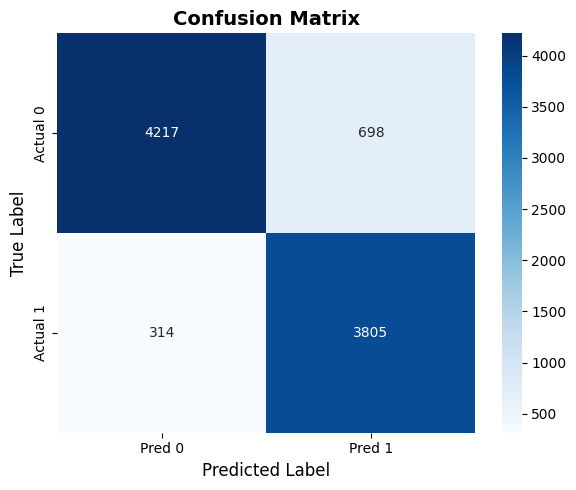

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_preds)



import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

## 22. Save Model and Results

In [34]:
os.makedirs("outputs", exist_ok=True)

torch.save(model.state_dict(), "outputs/debruijn_graphcl_gat_best_model.pt")
pd.DataFrame(history).to_csv("outputs/classification_history.csv", index=False)
pd.DataFrame({"ssl_loss": ssl_history}).to_csv("outputs/ssl_history.csv", index=False)

summary = {
    "K": K,
    "EMB_DIM": EMB_DIM,
    "HIDDEN_DIM": HIDDEN_DIM,
    "HEADS": HEADS,
    "PRETRAIN_EPOCHS": PRETRAIN_EPOCHS,
    "CLASSIFIER_EPOCHS": CLASSIFIER_EPOCHS,
    "Best_Val_F1": best_val_f1,
    "Best_Val_Acc": best_val_acc,
    "Test_Loss": test_loss,
    "Test_Acc": test_acc,
    "Test_F1": test_f1,
}

pd.DataFrame([summary]).to_csv("outputs/result_summary.csv", index=False)
print("Saved model and results in outputs/ folder.")
display(pd.DataFrame([summary]))

Saved model and results in outputs/ folder.


,K,EMB_DIM,HIDDEN_DIM,HEADS,PRETRAIN_EPOCHS,CLASSIFIER_EPOCHS,Best_Val_F1,Best_Val_Acc,Test_Loss,Test_Acc,Test_F1
0,6,64,384,6,100,80,0.886295,0.888561,0.311805,0.887093,0.883747


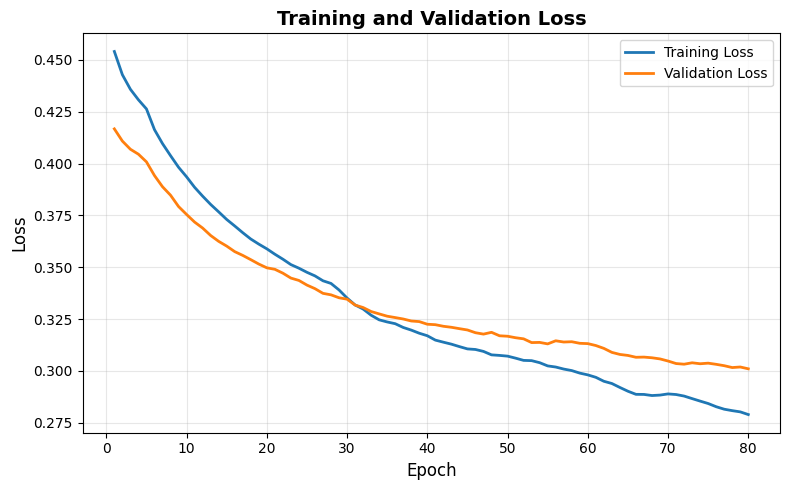

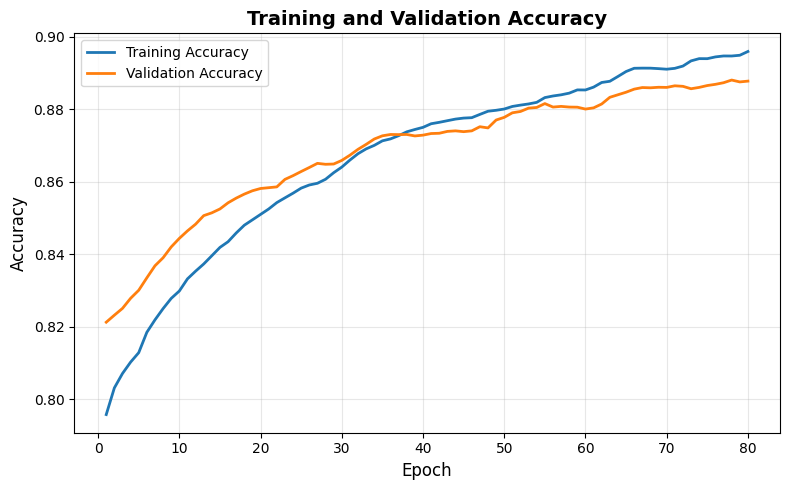

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

history_df = pd.DataFrame(history)

# 🔥 Smoothing function (moving average)
def smooth_curve(values, window=5):
    return pd.Series(values).rolling(window=window, min_periods=1).mean()

# =========================
# 1. Smooth Loss Curve
# =========================
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], smooth_curve(history_df["train_loss"]), linewidth=2, label="Training Loss")
plt.plot(history_df["epoch"], smooth_curve(history_df["val_loss"]), linewidth=2, label="Validation Loss")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training and Validation Loss", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("smooth_loss_curve.png", dpi=300)
plt.show()


# =========================
# 2. Smooth Accuracy Curve
# =========================
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], smooth_curve(history_df["train_acc"]), linewidth=2, label="Training Accuracy")
plt.plot(history_df["epoch"], smooth_curve(history_df["val_acc"]), linewidth=2, label="Validation Accuracy")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Training and Validation Accuracy", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("smooth_accuracy_curve.png", dpi=300)
plt.show()

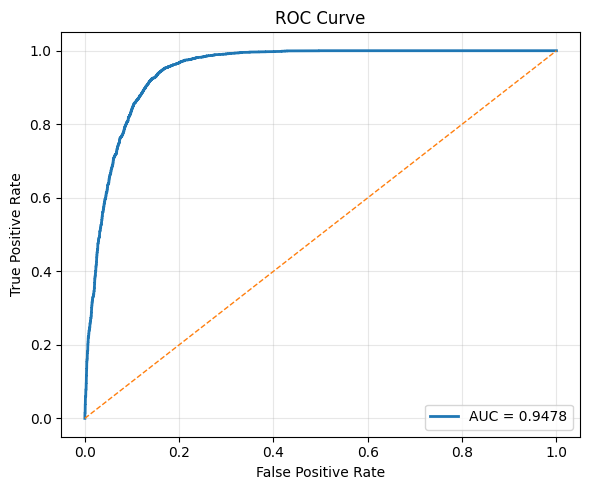

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability of class 1
y_probs = test_probs[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("roc_curve.png", dpi=300)
plt.show()

## Final Notes 

- The DNA sequence is converted into a De Bruijn graph.
- For `K = 6`, each node is a 5-mer and each edge is a 6-mer overlap.
- Reverse edges are added so GAT can pass messages in both directions.
- GraphCL learns graph representations before supervised classification.
- The final classifier is selected using best validation F1.

In [36]:
print(model)
print(test_loader)

GATClassifier(
  (encoder): GATEncoder(
    (embedding): Embedding(1024, 64)
    (gat1): GATConv(64, 64, heads=6)
    (gat2): GATConv(384, 64, heads=6)
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
